In [1]:
import sys
sys.path.append('../code')
sys.path.append('../externals/SIMNETS-Python/')

import os

import jax
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import numpy as np
from network_utils import (make_network, set_train_parameters, simulate, gaussian_tuning,
                           StimSynapse, get_currents, IonotropicSynapse, get_prior_dict)
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph
# from jaxley_mech.synapses.destexhe98 import AMPA, GABAa, GABAb, NMDA

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans

from tqdm import tqdm

import simnets

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

In [2]:
data_path =  '/users/ntolley/data/ntolley/dendractor/intrinsic_permutations/random_initialization'

file_list = os.listdir(data_path)

random_init_dict = dict()
for file_idx in tqdm(range(len(file_list))):
    with open(f'{data_path}/{file_list[file_idx]}', 'rb') as f:
        res_dict = pickle.load(f)
    
    random_init_dict[res_dict['name']] = res_dict

  0%|          | 0/9 [00:00<?, ?it/s]ERROR:2025-06-03 14:49:23,827:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/users/ntolley/.conda/envs/jaxley2/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 135, in _version_check
    version = get_version()
              ^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/users/ntolley/.conda/envs/jaxley2/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/users/ntolley/.conda/envs/jaxley2/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 230, in initialize
    _check_cuda_versions(raise_on_first_

In [3]:
print(list(random_init_dict.keys()))

['Edend_Idend', 'Edend_Isoma', 'Edend_Isomadend', 'Esoma_Idend', 'Esoma_Isoma', 'Esoma_Isomadend', 'Esomadend_Idend', 'Esomadend_Isoma', 'Esomadend_Isomadend']


In [4]:
# res_dict = random_init_dict['Esoma_Isoma']
res_dict = random_init_dict['Esoma_Idend']
# res_dict = random_init_dict['Esoma_Isomadend']

# res_dict = random_init_dict['Edend_Isoma']
# res_dict = random_init_dict['Edend_Idend']
# res_dict = random_init_dict['Edend_Isomadend']

# res_dict = random_init_dict['Esomadend_Isoma']
# res_dict = random_init_dict['Esomadend_Idend']
# res_dict = random_init_dict['Esomadend_Isomadend']


name = res_dict['name']
output_array = res_dict['output_array']
targets = res_dict['targets']
gid_ranges = res_dict['gid_ranges']
input_list = res_dict['input_list']
num_cond = input_list.shape[0]
print(name)

Esoma_Idend


In [5]:
t_max = 1000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
burn_in = int(0 / downsample_factor)

In [7]:
rate_gids = list(gid_ranges['E_rate'])
rates = output_array[:, rate_gids, :]

x_train = list()
for sim_idx in range(0, output_array.shape[0], num_cond):
    temp_list = list()
    for cond_idx in range(num_cond):
        temp_list.append(output_array[sim_idx + cond_idx, gid_ranges['E_rate'], :])
    x_train.append(np.concatenate(temp_list, axis=1).T)


num_train_sims = 5

error_list = list()
model = Ridge(alpha=2.0)
rate_fit = np.concatenate([x[burn_in:, :] for x in x_train[:num_train_sims]])
target_fit = np.concatenate([targets[burn_in:, :] for _ in range(num_train_sims)])
model.fit(rate_fit, target_fit)

for sim_idx in range(len(x_train)):
    rate_pred = x_train[sim_idx]
    y_pred = model.predict(rate_pred[burn_in:, :])


    error = np.mean(np.square(targets[burn_in:, :] - y_pred))
    error_list.append(error)

print(error_list[:num_train_sims])
print(error_list[num_train_sims:])

[np.float64(0.2592696382145898), np.float64(0.4160676449724634), np.float64(0.40407959403478316), np.float64(0.378316412764971), np.float64(0.31209793820576276)]
[np.float64(0.7284186658774159), np.float64(1.0401782722921808), np.float64(0.4876767489872556), np.float64(0.5309922682824397), np.float64(0.47027735477707416)]


In [8]:
y_pred_list = list()
target_list = list()

sim_start_idx = 9 * num_cond
for cond_idx in range(num_cond):
    rate_plot_data = output_array[sim_start_idx + cond_idx, gid_ranges['E_rate'], :].T
    y_pred = model.predict(rate_plot_data)

    y_pred_list.append(y_pred)
    target_list.append(res_dict['targets_stacked'][cond_idx, :, :].T)

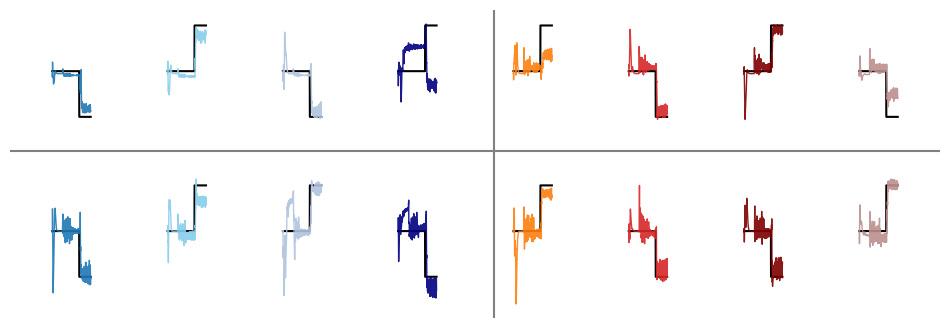

In [9]:
color_list = ['C0', 'skyblue', 'lightsteelblue', 'navy', 'C1', 'C3', 'maroon', 'rosybrown']
time_offset = 3000
y_offset = -7
plt.figure(figsize=(12,4))
for cond_idx in range(num_cond):
    x_offset = time_offset * cond_idx


    plt.plot(time_vec + x_offset, target_list[cond_idx][:-1, 0], color='k')
    plt.plot(time_vec + x_offset, y_pred_list[cond_idx][:-1, 0], color=color_list[cond_idx], alpha=0.9, linewidth=1)

    plt.plot(time_vec + x_offset, target_list[cond_idx][:-1, 1] + y_offset, color='k')
    plt.plot(time_vec + x_offset, y_pred_list[cond_idx][:-1, 1] + y_offset, color=color_list[cond_idx], alpha=0.9, linewidth=1)


    plt.axis('off')
plt.axhline(y_offset/2, color='grey', linestyle='-')
plt.axvline((time_offset * 4) - 500, color='grey', linestyle='-')
# plt.savefig('full_trajectory_set.svg')

In [10]:
input_names = [
    'Pro (-1,-1)', 'Pro (1,1)', 'Pro (-1,1)', 'Pro (1,-1)',
    'Anti (-1,-1)', 'Anti (1,1)', 'Anti (-1,1)', 'Anti (1,-1)']

In [11]:
gid_ranges

{'E': range(0, 50),
 'I': range(50, 75),
 'context': range(75, 100),
 'cue': range(100, 125),
 'E_rate': range(125, 175),
 'I_rate': range(175, 200)}

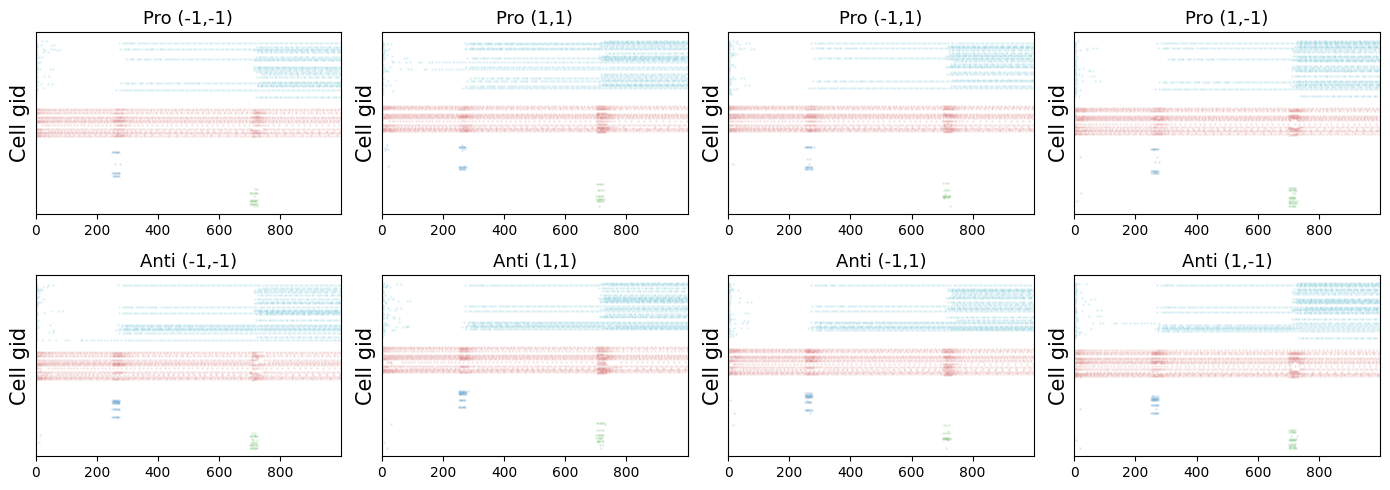

In [12]:
fontsize = 15
ticksize = 10
labelsize=13
threshold = 0.0

spike_color_dict = {'E': '#37abc8', 'I': '#d35f5f', 'context': '#1f77b4', 'cue': '#2ca02c'}
plt.figure(figsize=(14,5))
for plot_idx, sim_idx in enumerate(range(num_cond)):
    # sim_idx *= num_cond
    # sim_idx += 10
    
    plt.subplot(2,4, plot_idx+1)
    s = output_array[sim_idx, :]
    above_threshold = s > threshold
    spike_gids, spike_times = np.where(np.diff(above_threshold.astype(int), axis=1) == 1)

    for type_idx, (name, cell_range) in enumerate(gid_ranges.items()):
        if name not in ['output', 'E_rate', 'I_rate']:
            mask = np.isin(spike_gids, cell_range)
            plt.scatter(spike_times[mask] * dt, -spike_gids[mask] - type_idx * 10, label=name, s=1, alpha=0.1, color=spike_color_dict[name])
    plt.ylabel('Cell gid', fontsize=fontsize)
    plt.yticks([])
    plt.xlim(0, time_vec[-1])
    # plt.axvline(500 * dt, color='k', linestyle='--')
    plt.title(input_names[plot_idx], fontsize=labelsize)
    plt.tight_layout()

In [13]:
output_array.shape

(80, 200, 4001)

In [14]:
projection_args = {'n_components': 2, 'perplexity': 10, 'learning_rate': 5}
st_args = (30,)
# st_args = (1,)

model1 = simnets.SIMNETS(st_dist='victor-purpura', unit_dist='euclidean',
                         projection='TSNE', st_args=st_args)

cell_type_list = ['E', 'I']
st_data = list()
st_data_labels = list()
for cell_type in cell_type_list:
    for gid in gid_ranges[cell_type]:
        spike_times_list = list()
        spike_count = 0
        for sim_idx in range(output_array.shape[0]):
            s = output_array[sim_idx, gid, :]
            above_threshold = s > threshold
            spike_times = (np.where(np.diff(above_threshold.astype(int)) == 1)[0] + 1).astype(float)
            spike_times_list.append(spike_times)
        st_data.append(spike_times_list)
        st_data_labels.append(cell_type)
            
            
model1.fit(st_data)
_ = model1.project(projection_args=projection_args)

In [15]:
range_n_clusters = range(2,20)
silhouette_score_list = list()
for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(model1.simnets_points)
    silhouette_avg = silhouette_score(model1.simnets_points, cluster_labels)
    silhouette_score_list.append(silhouette_avg)

best_n_clusters = range_n_clusters[np.argmax(silhouette_score_list)]
print(f'Best cluster num: {best_n_clusters}')

clusterer = KMeans(n_clusters=best_n_clusters, random_state=10)
best_cluster_labels = clusterer.fit_predict(model1.simnets_points)

Best cluster num: 2


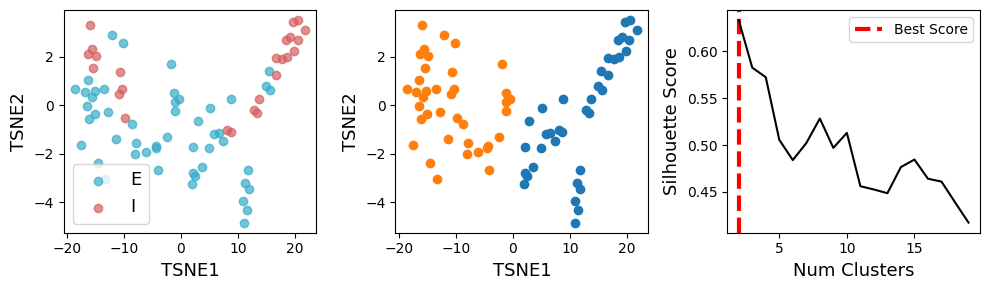

In [18]:
labelsize = 13
ticksize = 10
plt.figure(figsize=(10, 3))
plt.subplot(1,3,1)
for cell_type in cell_type_list:
    plot_gids = gid_ranges[cell_type]
    plt.scatter(model1.simnets_points[plot_gids,0], model1.simnets_points[plot_gids, 1],
                label=cell_type, color=spike_color_dict[cell_type], alpha=0.7)
plt.legend(fontsize=13)
plt.xlabel('TSNE1', fontsize=labelsize)
plt.ylabel('TSNE2', fontsize=labelsize)
plt.xticks(fontsize=ticksize)
plt.yticks(fontsize=ticksize)

plt.subplot(1,3,2)
for cluster_idx in np.unique(best_cluster_labels):
    plot_gids = best_cluster_labels == cluster_idx
    plt.scatter(model1.simnets_points[plot_gids,0], model1.simnets_points[plot_gids, 1],
                label=f'Cluster {cluster_idx}')
# plt.legend(fontsize=13)
plt.xlabel('TSNE1', fontsize=labelsize)
plt.ylabel('TSNE2', fontsize=labelsize)
plt.xticks(fontsize=ticksize)
plt.yticks(fontsize=ticksize)


plt.subplot(1,3,3)
plt.plot(range_n_clusters, silhouette_score_list, color='k')
plt.axvline(best_n_clusters, color='r', linewidth=3, linestyle='--', label='Best Score', zorder=-1)
plt.legend(fontsize=10)
plt.xlabel('Num Clusters', fontsize=labelsize)
plt.ylabel('Silhouette Score', fontsize=labelsize)
plt.xticks(fontsize=ticksize)
plt.yticks(fontsize=ticksize)

plt.tight_layout()

In [19]:
isi_dict = dict()
for cell_type in cell_type_list:
    cell_indices = np.where(np.array(st_data_labels) == cell_type)[0]
    isi_list = list()
    for cell_idx in cell_indices:
        isi = np.concatenate([np.diff(spike_times) for spike_times in st_data[cell_idx]])
        isi_list.append(isi)
    isi_dict[cell_type] = np.concatenate(isi_list) * dt


Text(0.5, 0, 'Interspike Interval (ms)')

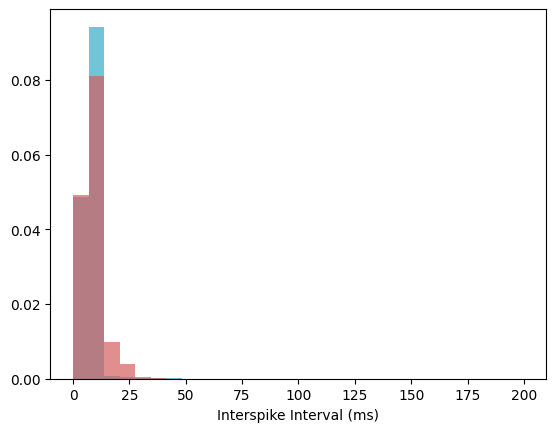

In [20]:
bins = np.linspace(0, 200, 30)
plt.hist(isi_dict['E'], bins=bins, alpha=0.7, density=True, color=spike_color_dict['E'])
plt.hist(isi_dict['I'], bins=bins, alpha=0.7, density=True, color=spike_color_dict['I'])
plt.xlabel('Interspike Interval (ms)')

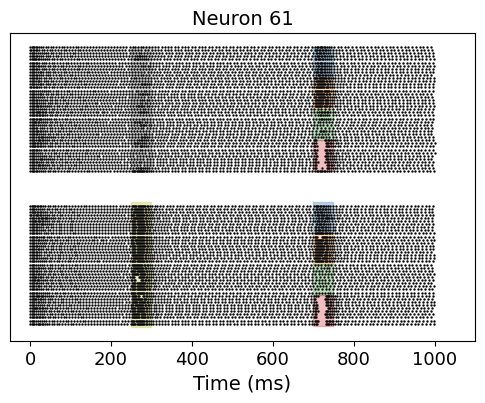

In [77]:
cell_idx = 61

ticksize = 13
labelsize = 14

num_repeats = output_array.shape[0] // num_cond
cond_order = [0,1,2,3,4,5,6,7]
trial_indices = list()
for cond_idx in range(num_cond):
    for repeat_idx in range(num_repeats):
        trial_indices.append((repeat_idx * num_cond) + cond_idx)

plt.figure(figsize=(6,4))

for plot_idx, trial_idx in enumerate(trial_indices):
    y_offset = 0
    if plot_idx > len(trial_indices) // 2:
        y_offset = 10

    st_trial = st_data[cell_idx][trial_idx] * dt
    y_pos = np.repeat(plot_idx, len(st_trial)) + y_offset
    plt.scatter(st_trial, y_pos, color='k', s=0.5)
plt.xlim(None, 1100)

plt.fill_between(x=[250, 300], y1=0, y2=4 * num_repeats, zorder=-0.9, alpha=0.3, color='C7', label='Pro')
plt.fill_between(x=[250, 300], y1=4 * num_repeats + 10, y2= 8 * num_repeats + 10, zorder=-0.9, alpha=0.3, color='C8', label='Anti')

cond_colors = [0,1,2,3,0,1,2,3]
cond_labels = ['(-1,-1)', '(1,1)', '(-1,1)', '(1,-1)',
               '(-1,-1)', '(1,1)', '(-1,1)', '(1,-1)']
for cond_idx in range(num_cond):
    y_offset = 0
    label = None
    if cond_idx > 3:
        y_offset = 10
        label = cond_labels[cond_idx]

    y1 = num_repeats * cond_idx - 0.1 + y_offset
    y2 = y1 + num_repeats
    plt.fill_between(x=[700, 750], y1=y1, y2=y2, zorder=-0.9, alpha=0.3, color=f'C{cond_colors[cond_idx]}', label=label)

_ = plt.yticks([])
_ = plt.xticks(fontsize=ticksize)

plt.xlabel('Time (ms)', fontsize=labelsize)
plt.title(f'Neuron {cell_idx}', fontsize=labelsize)
# plt.legend()
plt.gca().invert_yaxis()